In [71]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [72]:
train_data = pd.read_csv(r"Train.csv")
train_data.head()

,ID,Gender,Ever_Married,Age,Graduated,Profession,Work_Experience,Spending_Score,Family_Size,Var_1,Segmentation
0,462809,Male,No,22,No,Healthcare,1.0,Low,4.0,Cat_4,D
1,462643,Female,Yes,38,Yes,Engineer,NaN,Average,3.0,Cat_4,A
2,466315,Female,Yes,67,Yes,Engineer,1.0,Low,1.0,Cat_6,B
3,461735,Male,Yes,67,Yes,Lawyer,0.0,High,2.0,Cat_6,B
4,462669,Female,Yes,40,Yes,Entertainment,NaN,High,6.0,Cat_6,A


In [73]:
test_data = pd.read_csv(r"Test.csv")
test_data.head()

,ID,Gender,Ever_Married,Age,Graduated,Profession,Work_Experience,Spending_Score,Family_Size,Var_1,Segmentation
0,458989,Female,Yes,36,Yes,Engineer,0.0,Low,1.0,Cat_6,B
1,458994,Male,Yes,37,Yes,Healthcare,8.0,Average,4.0,Cat_6,A
2,458996,Female,Yes,69,No,NaN,0.0,Low,1.0,Cat_6,A
3,459000,Male,Yes,59,No,Executive,11.0,High,2.0,Cat_6,B
4,459001,Female,No,19,No,Marketing,NaN,Low,4.0,Cat_6,A


In [74]:
train_data.shape , test_data.shape

((8068, 11), (2627, 11))

In [75]:
train_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 8068 entries, 0 to 8067
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ID               8068 non-null   int64  
 1   Gender           8068 non-null   str    
 2   Ever_Married     7928 non-null   str    
 3   Age              8068 non-null   int64  
 4   Graduated        7990 non-null   str    
 5   Profession       7944 non-null   str    
 6   Work_Experience  7239 non-null   float64
 7   Spending_Score   8068 non-null   str    
 8   Family_Size      7733 non-null   float64
 9   Var_1            7992 non-null   str    
 10  Segmentation     8068 non-null   str    
dtypes: float64(2), int64(2), str(7)
memory usage: 918.9 KB


In [76]:
train_data.describe()

,ID,Age,Work_Experience,Family_Size
count,8068.000000,8068.000000,7239.000000,7733.000000
mean,463479.214551,43.466906,2.641663,2.850123
std,2595.381232,16.711696,3.406763,1.531413
min,458982.000000,18.000000,0.000000,1.000000
25%,461240.750000,30.000000,0.000000,2.000000
50%,463472.500000,40.000000,1.000000,3.000000
75%,465744.250000,53.000000,4.000000,4.000000
max,467974.000000,89.000000,14.000000,9.000000


In [77]:
test_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 2627 entries, 0 to 2626
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ID               2627 non-null   int64  
 1   Gender           2627 non-null   str    
 2   Ever_Married     2577 non-null   str    
 3   Age              2627 non-null   int64  
 4   Graduated        2603 non-null   str    
 5   Profession       2589 non-null   str    
 6   Work_Experience  2358 non-null   float64
 7   Spending_Score   2627 non-null   str    
 8   Family_Size      2514 non-null   float64
 9   Var_1            2595 non-null   str    
 10  Segmentation     2627 non-null   str    
dtypes: float64(2), int64(2), str(7)
memory usage: 299.1 KB


In [78]:
test_data.describe()

,ID,Age,Work_Experience,Family_Size
count,2627.000000,2627.000000,2358.000000,2514.000000
mean,463433.918919,43.649791,2.552587,2.825378
std,2618.245698,16.967015,3.341094,1.551906
min,458989.000000,18.000000,0.000000,1.000000
25%,461162.500000,30.000000,0.000000,2.000000
50%,463379.000000,41.000000,1.000000,2.000000
75%,465696.000000,53.000000,4.000000,4.000000
max,467968.000000,89.000000,14.000000,9.000000


In [79]:
for col in train_data.columns:
    print(col, train_data[col].unique())
    print("-" *35)

ID [462809 462643 466315 ... 465406 467299 461879]
-----------------------------------
Gender <ArrowStringArray>
['Male', 'Female']
Length: 2, dtype: str
-----------------------------------
Ever_Married <ArrowStringArray>
['No', 'Yes', nan]
Length: 3, dtype: str
-----------------------------------
Age [22 38 67 40 56 32 33 61 55 26 19 70 58 41 31 79 49 18 36 35 45 42 83 27
 28 47 29 57 76 25 72 48 74 59 39 51 30 63 52 60 68 86 50 43 80 37 46 69
 78 71 82 23 20 85 21 53 62 75 65 89 66 73 77 87 84 81 88]
-----------------------------------
Graduated <ArrowStringArray>
['No', 'Yes', nan]
Length: 3, dtype: str
-----------------------------------
Profession <ArrowStringArray>
[   'Healthcare',      'Engineer',        'Lawyer', 'Entertainment',
        'Artist',     'Executive',        'Doctor',     'Homemaker',
     'Marketing',             nan]
Length: 10, dtype: str
-----------------------------------
Work_Experience [ 1. nan  0.  4.  9. 12.  3. 13.  5.  8. 14.  7.  2.  6. 10. 11.]
------

In [80]:
for col in test_data.columns:
    print(col, test_data[col].unique())
    print("-"*35)

ID [458989 458994 458996 ... 467960 467961 467968]
-----------------------------------
Gender <ArrowStringArray>
['Female', 'Male']
Length: 2, dtype: str
-----------------------------------
Ever_Married <ArrowStringArray>
['Yes', 'No', nan]
Length: 3, dtype: str
-----------------------------------
Age [36 37 69 59 19 47 61 50 22 27 18 20 45 55 88 63 42 79 35 52 29 87 89 31
 72 41 62 56 60 68 57 51 86 74 23 80 78 48 70 83 73 46 43 32 39 71 67 49
 65 33 58 30 21 26 81 28 76 85 66 53 40 25 77 75 82 84 38]
-----------------------------------
Graduated <ArrowStringArray>
['Yes', 'No', nan]
Length: 3, dtype: str
-----------------------------------
Profession <ArrowStringArray>
[     'Engineer',    'Healthcare',             nan,     'Executive',
     'Marketing',        'Doctor',        'Artist',        'Lawyer',
 'Entertainment',     'Homemaker']
Length: 10, dtype: str
-----------------------------------
Work_Experience [ 0.  8. 11. nan  5.  1.  2.  9.  3.  6.  7.  4. 13. 10. 12. 14.]
------

# Handling Missing Values

In [81]:
train_data = train_data.drop('ID',axis=1)

In [82]:
test_data = test_data.drop('ID',axis=1)

In [83]:
train_data.isna().sum().sort_values(ascending=False)

Work_Experience    829
Family_Size        335
Ever_Married       140
Profession         124
Graduated           78
Var_1               76
Gender               0
Age                  0
Spending_Score       0
Segmentation         0
dtype: int64

In [84]:
test_data.isna().sum().sort_values(ascending=False)

Work_Experience    269
Family_Size        113
Ever_Married        50
Profession          38
Var_1               32
Graduated           24
Gender               0
Age                  0
Spending_Score       0
Segmentation         0
dtype: int64

In [85]:
# get numeric columns from 'train_data'
numeric_cols = train_data.select_dtypes(include='number').columns
numeric_cols

Index(['Age', 'Work_Experience', 'Family_Size'], dtype='str')

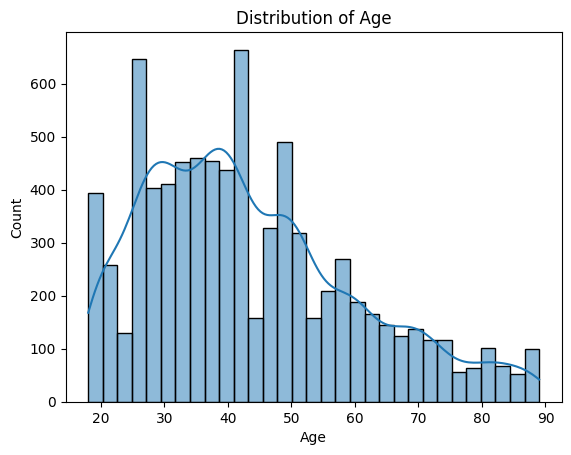

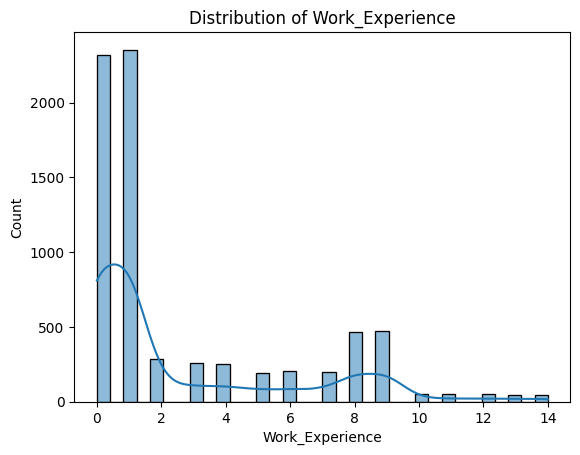

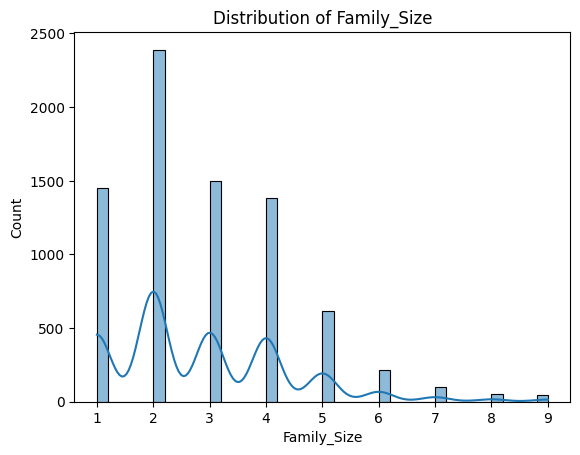

In [86]:
for col in numeric_cols:
    sns.histplot(train_data[col], kde=True)
    plt.title(f"Distribution of {col}")
    plt.show()

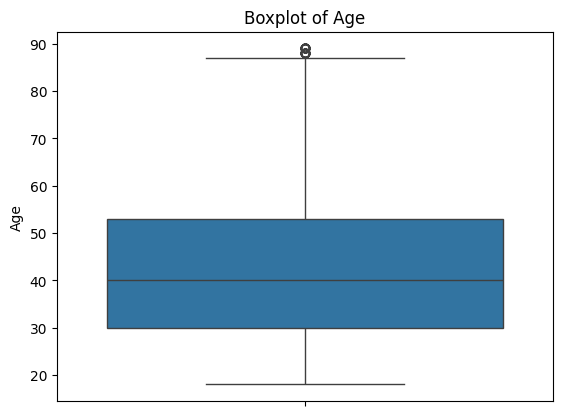

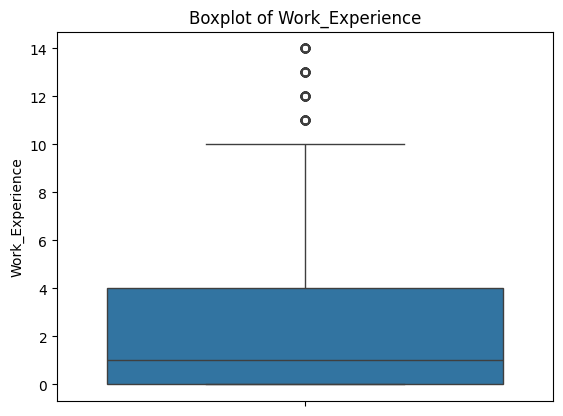

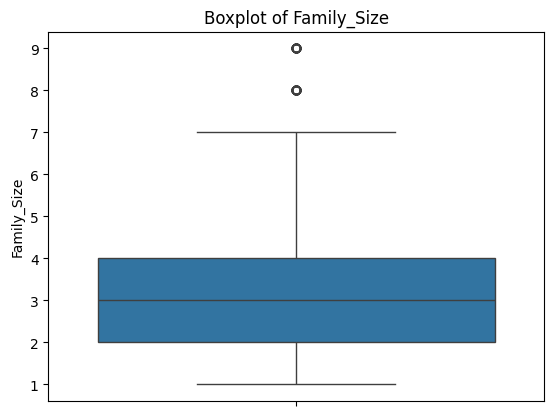

In [87]:
# boxplot
for col in numeric_cols:
    sns.boxplot(train_data[col])
    plt.title(f"Boxplot of {col}")
    plt.show()

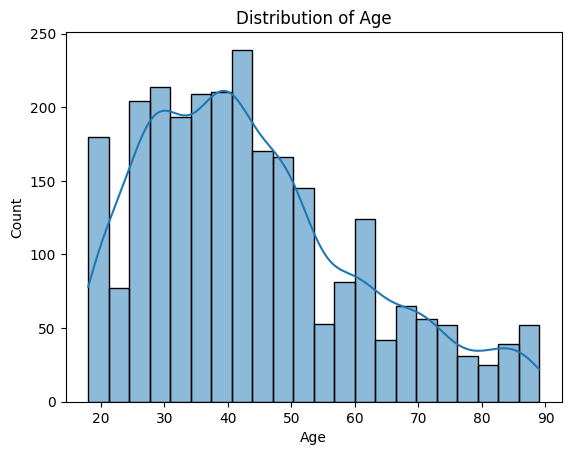

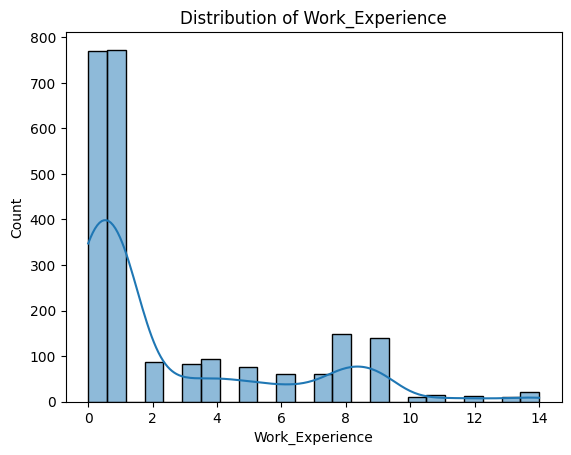

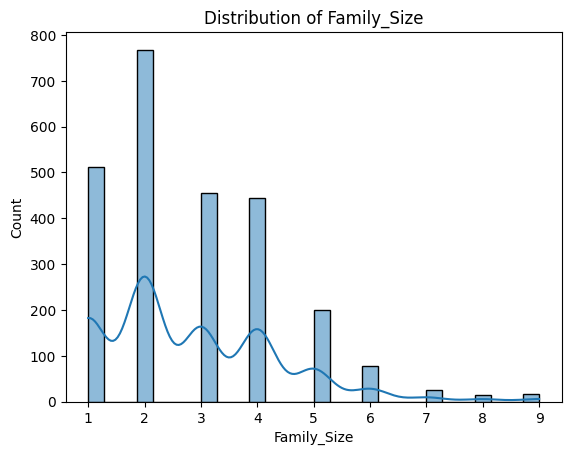

In [88]:
# test_data 
numeric_cols = test_data.select_dtypes(include='number').columns
for col in numeric_cols:
    sns.histplot(test_data[col], kde=True)
    plt.title(f"Distribution of {col}")
    plt.show()

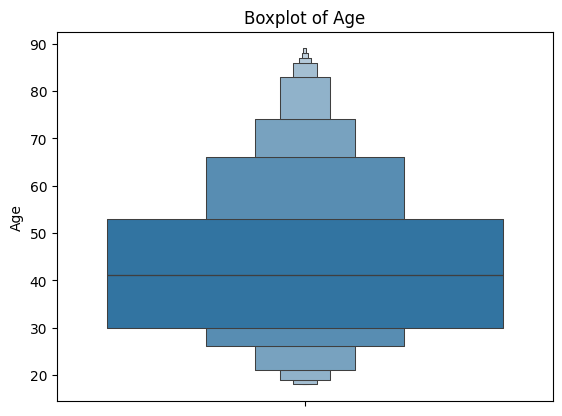

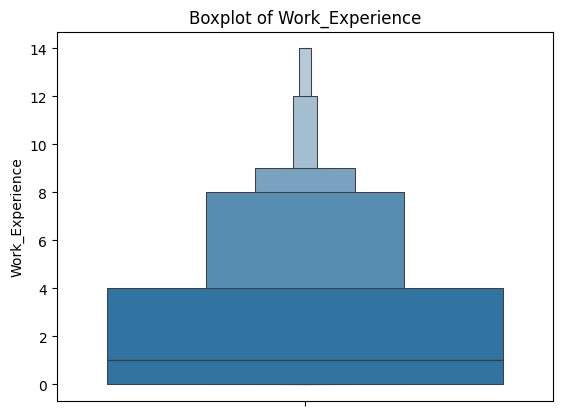

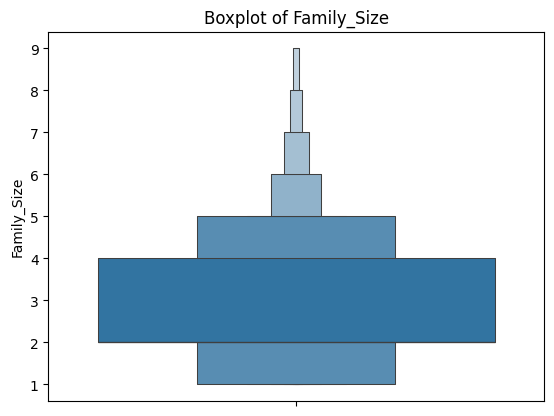

In [89]:
for col in numeric_cols:
    sns.boxenplot(test_data[col])
    plt.title(f"Boxplot of {col}")
    plt.show()

In [90]:
skew_train = train_data.select_dtypes(include='number').skew()
skew_test = test_data.select_dtypes(include='number').skew()
print(skew_train, skew_test)

Age                0.696021
Work_Experience    1.306226
Family_Size        1.010804
dtype: float64 Age                0.704448
Work_Experience    1.388658
Family_Size        1.008504
dtype: float64


In [91]:
train_data.isna().sum().sort_values(ascending=False)

Work_Experience    829
Family_Size        335
Ever_Married       140
Profession         124
Graduated           78
Var_1               76
Gender               0
Age                  0
Spending_Score       0
Segmentation         0
dtype: int64

In [92]:
test_data.isna().sum().sort_values(ascending=False)

Work_Experience    269
Family_Size        113
Ever_Married        50
Profession          38
Var_1               32
Graduated           24
Gender               0
Age                  0
Spending_Score       0
Segmentation         0
dtype: int64

In [93]:
from sklearn.impute import SimpleImputer

In [94]:
imputer = SimpleImputer(missing_values=np.nan, strategy='median')
numeric_cols = train_data.select_dtypes(include='number').columns
imputer.fit(train_data[numeric_cols])

train_data[numeric_cols] = imputer.transform(train_data[numeric_cols])
test_data[numeric_cols] = imputer.transform(test_data[numeric_cols])

In [95]:
test_data.isna().sum().sort_values(ascending=False)

Ever_Married       50
Profession         38
Var_1              32
Graduated          24
Gender              0
Age                 0
Work_Experience     0
Spending_Score      0
Family_Size         0
Segmentation        0
dtype: int64

In [96]:
test_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 2627 entries, 0 to 2626
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Gender           2627 non-null   str    
 1   Ever_Married     2577 non-null   str    
 2   Age              2627 non-null   float64
 3   Graduated        2603 non-null   str    
 4   Profession       2589 non-null   str    
 5   Work_Experience  2627 non-null   float64
 6   Spending_Score   2627 non-null   str    
 7   Family_Size      2627 non-null   float64
 8   Var_1            2595 non-null   str    
 9   Segmentation     2627 non-null   str    
dtypes: float64(3), str(7)
memory usage: 278.6 KB


In [97]:
imputer = SimpleImputer(missing_values=np.nan, strategy='most_frequent')
str_cols = train_data.select_dtypes(include='str').columns
imputer.fit(train_data[str_cols])

train_data[str_cols] = imputer.transform(train_data[str_cols])
test_data[str_cols] = imputer.transform(test_data[str_cols])

In [98]:
test_data.isna().sum()

Gender             0
Ever_Married       0
Age                0
Graduated          0
Profession         0
Work_Experience    0
Spending_Score     0
Family_Size        0
Var_1              0
Segmentation       0
dtype: int64

In [99]:
train_data.isna().sum()

Gender             0
Ever_Married       0
Age                0
Graduated          0
Profession         0
Work_Experience    0
Spending_Score     0
Family_Size        0
Var_1              0
Segmentation       0
dtype: int64

# duplicated check

In [100]:
train_data.duplicated().sum()

np.int64(544)

In [101]:
test_data.duplicated().sum()

np.int64(36)

In [102]:
train_data = train_data.drop_duplicates()
test_data = test_data.drop_duplicates()

In [103]:
test_data.duplicated().sum()

np.int64(0)

In [104]:
train_data.duplicated().sum()

np.int64(0)

# visualization

In [105]:
numeric_col = train_data.select_dtypes(include='number')
corr = numeric_col.corr()
corr

,Age,Work_Experience,Family_Size
Age,1.000000,-0.193268,-0.258490
Work_Experience,-0.193268,1.000000,-0.059055
Family_Size,-0.258490,-0.059055,1.000000


<Axes: >

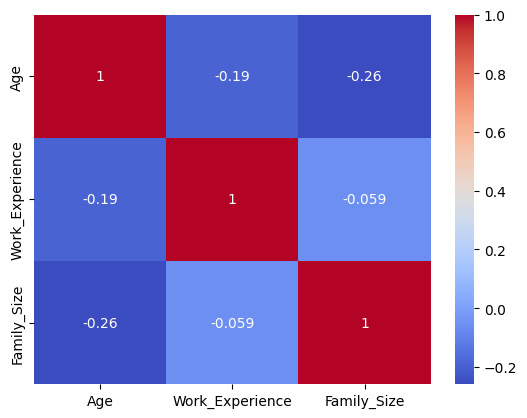

In [106]:
sns.heatmap(corr, annot=True, cmap='coolwarm')

# Outliers check

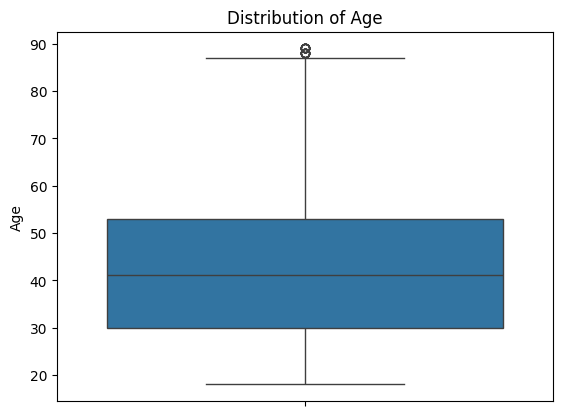

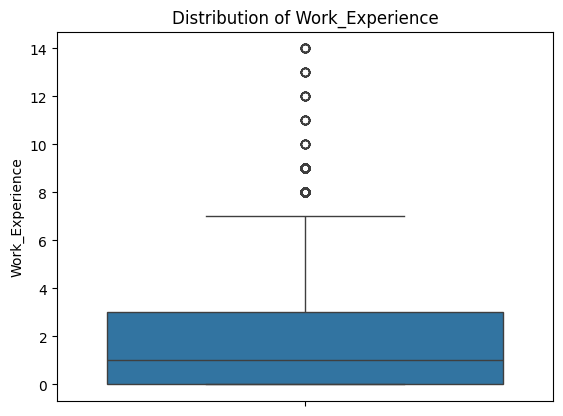

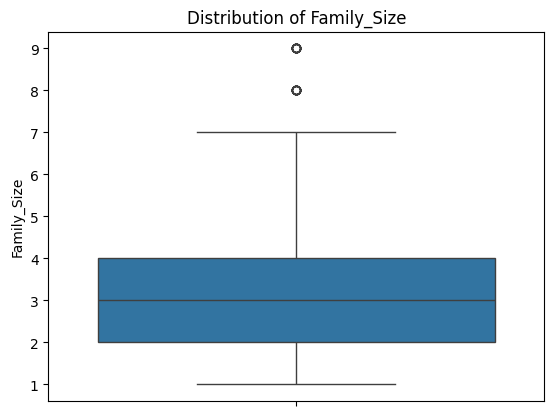

In [107]:
numeric_cols = test_data.select_dtypes(include='number').columns
for col in numeric_cols:
    sns.boxplot(test_data[col])
    plt.title(f"Distribution of {col}")
    plt.show()

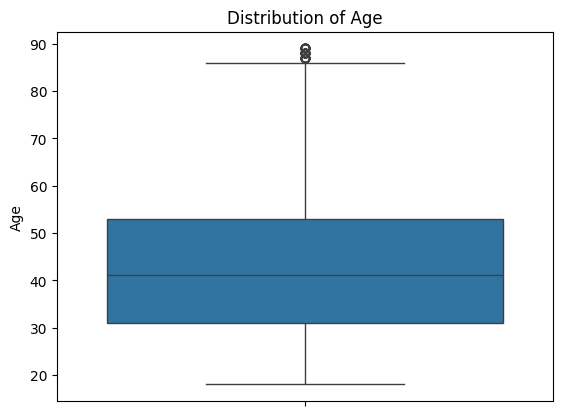

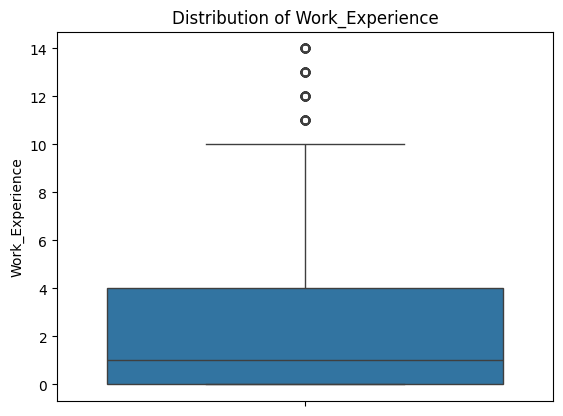

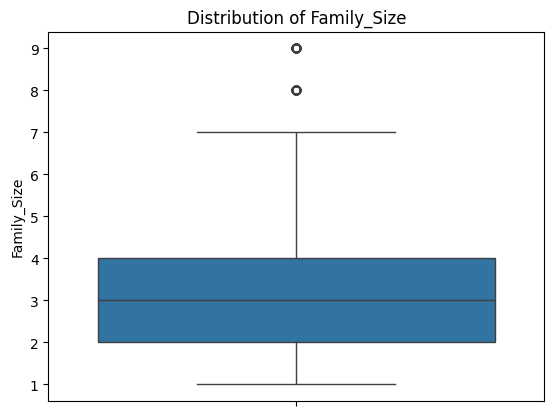

In [108]:
numeric_cols = train_data.select_dtypes(include='number').columns
for col in numeric_cols:
    sns.boxplot(train_data[col])
    plt.title(f"Distribution of {col}")
    plt.show()

In [109]:
train_data.shape, test_data.shape

((7524, 10), (2591, 10))

In [110]:
numeric_cols = train_data.select_dtypes(include='number').columns
outliers_train = {}

for col in numeric_cols:
    q1 = train_data[col].quantile(0.25)
    q3 = train_data[col].quantile(0.75)
    iqr = q3 - q1

    outliers = train_data[(train_data[col] < (q1 - 1.5 * iqr)) | (train_data[col] > (q3 + 1.5 * iqr))]
    outliers_train[col] = outliers.shape[0]

print(outliers_train)

{'Age': 87, 'Work_Experience': 189, 'Family_Size': 94}


In [111]:
train_data.shape, test_data.shape

((7524, 10), (2591, 10))

# Encoding

In [112]:
for col in train_data.select_dtypes(include='str').columns:
    print(col, train_data[col].dtype)
    print(col, train_data[col].unique())
    print("-"*35)

Gender str
Gender <ArrowStringArray>
['Male', 'Female']
Length: 2, dtype: str
-----------------------------------
Ever_Married str
Ever_Married <ArrowStringArray>
['No', 'Yes']
Length: 2, dtype: str
-----------------------------------
Graduated str
Graduated <ArrowStringArray>
['No', 'Yes']
Length: 2, dtype: str
-----------------------------------
Profession str
Profession <ArrowStringArray>
[   'Healthcare',      'Engineer',        'Lawyer', 'Entertainment',
        'Artist',     'Executive',        'Doctor',     'Homemaker',
     'Marketing']
Length: 9, dtype: str
-----------------------------------
Spending_Score str
Spending_Score <ArrowStringArray>
['Low', 'Average', 'High']
Length: 3, dtype: str
-----------------------------------
Var_1 str
Var_1 <ArrowStringArray>
['Cat_4', 'Cat_6', 'Cat_7', 'Cat_3', 'Cat_1', 'Cat_2', 'Cat_5']
Length: 7, dtype: str
-----------------------------------
Segmentation str
Segmentation <ArrowStringArray>
['D', 'A', 'B', 'C']
Length: 4, dtype: str
----

In [113]:
label_list = ['Graduated','Ever_Married','Gender']

from sklearn.preprocessing import LabelEncoder


In [114]:
for i in label_list:
    label = LabelEncoder()
    train_data[i] = label.fit_transform(train_data[i])
    test_data[i] = label.fit_transform(test_data[i])

In [115]:
for col in label_list:
    print(col, train_data[col].unique())
    print(col, test_data[col].unique())

Graduated [0 1]
Graduated [1 0]
Ever_Married [0 1]
Ever_Married [1 0]
Gender [1 0]
Gender [0 1]


In [116]:
train_data.head()

,Gender,Ever_Married,Age,Graduated,Profession,Work_Experience,Spending_Score,Family_Size,Var_1,Segmentation
0,1,0,22.0,0,Healthcare,1.0,Low,4.0,Cat_4,D
1,0,1,38.0,1,Engineer,1.0,Average,3.0,Cat_4,A
2,0,1,67.0,1,Engineer,1.0,Low,1.0,Cat_6,B
3,1,1,67.0,1,Lawyer,0.0,High,2.0,Cat_6,B
4,0,1,40.0,1,Entertainment,1.0,High,6.0,Cat_6,A


In [117]:
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder

In [118]:
onehot = OneHotEncoder()
onehot_for_spendingscore = (onehot.fit_transform(train_data[['Spending_Score']])).toarray()
onehot_for_spendingscore_test = (onehot.fit_transform(test_data[['Spending_Score']])).toarray()

In [119]:
spending = pd.DataFrame(onehot_for_spendingscore,columns=onehot.get_feature_names_out(), index=train_data.index)
spending_test = pd.DataFrame(onehot_for_spendingscore_test, columns=onehot.get_feature_names_out(), index=test_data.index)

train_data = pd.concat([train_data, spending], axis=1)
test_data=pd.concat([test_data,spending_test], axis=1)

train_data = train_data.drop('Spending_Score', axis=1)
test_data = test_data.drop('Spending_Score',axis=1)

In [120]:
train_data.head()

,Gender,Ever_Married,Age,Graduated,Profession,Work_Experience,Family_Size,Var_1,Segmentation,Spending_Score_Average,Spending_Score_High,Spending_Score_Low
0,1,0,22.0,0,Healthcare,1.0,4.0,Cat_4,D,0.0,0.0,1.0
1,0,1,38.0,1,Engineer,1.0,3.0,Cat_4,A,1.0,0.0,0.0
2,0,1,67.0,1,Engineer,1.0,1.0,Cat_6,B,0.0,0.0,1.0
3,1,1,67.0,1,Lawyer,0.0,2.0,Cat_6,B,0.0,1.0,0.0
4,0,1,40.0,1,Entertainment,1.0,6.0,Cat_6,A,0.0,1.0,0.0


In [121]:
test_data.head()

,Gender,Ever_Married,Age,Graduated,Profession,Work_Experience,Family_Size,Var_1,Segmentation,Spending_Score_Average,Spending_Score_High,Spending_Score_Low
0,0,1,36.0,1,Engineer,0.0,1.0,Cat_6,B,0.0,0.0,1.0
1,1,1,37.0,1,Healthcare,8.0,4.0,Cat_6,A,1.0,0.0,0.0
2,0,1,69.0,0,Artist,0.0,1.0,Cat_6,A,0.0,0.0,1.0
3,1,1,59.0,0,Executive,11.0,2.0,Cat_6,B,0.0,1.0,0.0
4,0,0,19.0,0,Marketing,1.0,4.0,Cat_6,A,0.0,0.0,1.0


In [122]:
onehot = OneHotEncoder()
onehot_profession = (onehot.fit_transform(train_data[['Profession']])).toarray()
onehot_profession_test = (onehot.fit_transform(test_data[['Profession']])).toarray()

profession = pd.DataFrame(onehot_profession, columns = onehot.get_feature_names_out(), index=train_data.index)
profession_test = pd.DataFrame(onehot_profession_test, columns=onehot.get_feature_names_out(), index=test_data.index)

train_data = pd.concat([train_data,profession], axis=1)
test_data = pd.concat([test_data,profession_test], axis=1)

train_data = train_data.drop(['Profession'], axis=1)
test_data = test_data.drop(['Profession'], axis=1)

In [123]:
train_data.head()

,Gender,Ever_Married,Age,Graduated,Work_Experience,Family_Size,Var_1,Segmentation,Spending_Score_Average,Spending_Score_High,Spending_Score_Low,Profession_Artist,Profession_Doctor,Profession_Engineer,Profession_Entertainment,Profession_Executive,Profession_Healthcare,Profession_Homemaker,Profession_Lawyer,Profession_Marketing
0,1,0,22.0,0,1.0,4.0,Cat_4,D,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
1,0,1,38.0,1,1.0,3.0,Cat_4,A,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0,1,67.0,1,1.0,1.0,Cat_6,B,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
3,1,1,67.0,1,0.0,2.0,Cat_6,B,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
4,0,1,40.0,1,1.0,6.0,Cat_6,A,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0


In [124]:
test_data.head()

,Gender,Ever_Married,Age,Graduated,Work_Experience,Family_Size,Var_1,Segmentation,Spending_Score_Average,Spending_Score_High,Spending_Score_Low,Profession_Artist,Profession_Doctor,Profession_Engineer,Profession_Entertainment,Profession_Executive,Profession_Healthcare,Profession_Homemaker,Profession_Lawyer,Profession_Marketing
0,0,1,36.0,1,0.0,1.0,Cat_6,B,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
1,1,1,37.0,1,8.0,4.0,Cat_6,A,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
2,0,1,69.0,0,0.0,1.0,Cat_6,A,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,1,1,59.0,0,11.0,2.0,Cat_6,B,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
4,0,0,19.0,0,1.0,4.0,Cat_6,A,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


In [125]:
train_data.info()

<class 'pandas.DataFrame'>
Index: 7524 entries, 0 to 8067
Data columns (total 20 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Gender                    7524 non-null   int64  
 1   Ever_Married              7524 non-null   int64  
 2   Age                       7524 non-null   float64
 3   Graduated                 7524 non-null   int64  
 4   Work_Experience           7524 non-null   float64
 5   Family_Size               7524 non-null   float64
 6   Var_1                     7524 non-null   str    
 7   Segmentation              7524 non-null   str    
 8   Spending_Score_Average    7524 non-null   float64
 9   Spending_Score_High       7524 non-null   float64
 10  Spending_Score_Low        7524 non-null   float64
 11  Profession_Artist         7524 non-null   float64
 12  Profession_Doctor         7524 non-null   float64
 13  Profession_Engineer       7524 non-null   float64
 14  Profession_Entertainment

In [126]:
for col in train_data.select_dtypes('str').columns:
    print(col, train_data[col].dtype)
    print(col, train_data[col].unique())
    print("-"*35)

Var_1 str
Var_1 <ArrowStringArray>
['Cat_4', 'Cat_6', 'Cat_7', 'Cat_3', 'Cat_1', 'Cat_2', 'Cat_5']
Length: 7, dtype: str
-----------------------------------
Segmentation str
Segmentation <ArrowStringArray>
['D', 'A', 'B', 'C']
Length: 4, dtype: str
-----------------------------------


In [127]:
Var = {
    'Cat_4': 1,
    'Cat_6': 2,
    'Cat_7': 3,
    'Cat_3': 4,
    'Cat_1': 5,
    'Cat_2':6,
    'Cat_5':7
}
train_data['Var_1'] = train_data['Var_1'].map(Var)
test_data['Var_1'] = test_data['Var_1'].map(Var)

In [129]:
SEG = {
    'D': 0,
    'C': 1,
    'B': 2,
    'A': 3
}
train_data['Segmentation'] = train_data['Segmentation'].map(SEG)
test_data['Segmentation'] = test_data['Segmentation'].map(SEG)

In [130]:
train_data.head()

,Gender,Ever_Married,Age,Graduated,Work_Experience,Family_Size,Var_1,Segmentation,Spending_Score_Average,Spending_Score_High,Spending_Score_Low,Profession_Artist,Profession_Doctor,Profession_Engineer,Profession_Entertainment,Profession_Executive,Profession_Healthcare,Profession_Homemaker,Profession_Lawyer,Profession_Marketing
0,1,0,22.0,0,1.0,4.0,1,0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
1,0,1,38.0,1,1.0,3.0,1,3,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0,1,67.0,1,1.0,1.0,2,2,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
3,1,1,67.0,1,0.0,2.0,2,2,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
4,0,1,40.0,1,1.0,6.0,2,3,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0


In [131]:
test_data.head()

,Gender,Ever_Married,Age,Graduated,Work_Experience,Family_Size,Var_1,Segmentation,Spending_Score_Average,Spending_Score_High,Spending_Score_Low,Profession_Artist,Profession_Doctor,Profession_Engineer,Profession_Entertainment,Profession_Executive,Profession_Healthcare,Profession_Homemaker,Profession_Lawyer,Profession_Marketing
0,0,1,36.0,1,0.0,1.0,2,2,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
1,1,1,37.0,1,8.0,4.0,2,3,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
2,0,1,69.0,0,0.0,1.0,2,3,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,1,1,59.0,0,11.0,2.0,2,2,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
4,0,0,19.0,0,1.0,4.0,2,3,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


# Spliting DATA

In [132]:
X_train = train_data.drop(['Segmentation'],axis=1)

In [133]:
y_train = train_data['Segmentation']

In [134]:
X_test = test_data.drop(['Segmentation'],axis=1)

In [135]:
y_test = test_data['Segmentation']

In [136]:
X_train.head()

,Gender,Ever_Married,Age,Graduated,Work_Experience,Family_Size,Var_1,Spending_Score_Average,Spending_Score_High,Spending_Score_Low,Profession_Artist,Profession_Doctor,Profession_Engineer,Profession_Entertainment,Profession_Executive,Profession_Healthcare,Profession_Homemaker,Profession_Lawyer,Profession_Marketing
0,1,0,22.0,0,1.0,4.0,1,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
1,0,1,38.0,1,1.0,3.0,1,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0,1,67.0,1,1.0,1.0,2,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
3,1,1,67.0,1,0.0,2.0,2,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
4,0,1,40.0,1,1.0,6.0,2,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0


In [137]:
y_train.head()

0    0
1    3
2    2
3    2
4    3
Name: Segmentation, dtype: int64

In [138]:
X_test.head()

,Gender,Ever_Married,Age,Graduated,Work_Experience,Family_Size,Var_1,Spending_Score_Average,Spending_Score_High,Spending_Score_Low,Profession_Artist,Profession_Doctor,Profession_Engineer,Profession_Entertainment,Profession_Executive,Profession_Healthcare,Profession_Homemaker,Profession_Lawyer,Profession_Marketing
0,0,1,36.0,1,0.0,1.0,2,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
1,1,1,37.0,1,8.0,4.0,2,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
2,0,1,69.0,0,0.0,1.0,2,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,1,1,59.0,0,11.0,2.0,2,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
4,0,0,19.0,0,1.0,4.0,2,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


In [139]:
y_test.head()

0    2
1    3
2    3
3    2
4    3
Name: Segmentation, dtype: int64

# Scaling

In [140]:
from sklearn.preprocessing import MinMaxScaler

In [142]:
scaler = MinMaxScaler()
X_train = scaler.fit_transform(X_train)
X_train

array([[1.        , 0.        , 0.05633803, ..., 0.        , 0.        ,
        0.        ],
       [0.        , 1.        , 0.28169014, ..., 0.        , 0.        ,
        0.        ],
       [0.        , 1.        , 0.69014085, ..., 0.        , 0.        ,
        0.        ],
       ...,
       [1.        , 0.        , 0.05633803, ..., 0.        , 0.        ,
        0.        ],
       [1.        , 0.        , 0.23943662, ..., 0.        , 0.        ,
        0.        ],
       [1.        , 1.        , 0.26760563, ..., 0.        , 0.        ,
        0.        ]], shape=(7524, 19))

In [143]:
X_test = scaler.fit_transform(X_test)
X_test

array([[0.        , 1.        , 0.25352113, ..., 0.        , 0.        ,
        0.        ],
       [1.        , 1.        , 0.26760563, ..., 0.        , 0.        ,
        0.        ],
       [0.        , 1.        , 0.71830986, ..., 0.        , 0.        ,
        0.        ],
       ...,
       [0.        , 0.        , 0.49295775, ..., 0.        , 0.        ,
        0.        ],
       [1.        , 1.        , 0.4084507 , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.35211268, ..., 0.        , 0.        ,
        0.        ]], shape=(2591, 19))

In [145]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB


In [146]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

In [147]:
models = {
    'LogisticRegression': LogisticRegression(),
    'DecisionTreeClassifier': DecisionTreeClassifier(),
    'RandomForestClassifier': RandomForestClassifier(),
    'SVC': SVC(),
    'KNeighborsClassifier': KNeighborsClassifier(),
    'GaussianNB': GaussianNB(),
    
}

In [148]:
accuracy = []

In [149]:
for name, model in models.items():
    model.fit(X_train,y_train)
    y_pred_train = model.predict(X_train)
    y_pred_test = model.predict(X_test)

    acc_train = accuracy_score(y_train,y_pred_train)
    acc_test = accuracy_score(y_test,y_pred_test)

    pre_train = precision_score(y_train,y_pred_train, average='macro')
    pre_test = precision_score(y_test,y_pred_test, average='macro')

    rec_train = recall_score(y_train,y_pred_train, average='macro')
    rec_test = recall_score(y_test,y_pred_test,average='macro')

    f1_train = f1_score(y_train,y_pred_train,average='macro')
    f1_test = f1_score(y_test,y_pred_test,average='macro')

    accuracy.append([acc_train,pre_train,rec_train,f1_train,acc_test,pre_test,rec_test,f1_test])

In [150]:
accuracy

[[0.4946836788942052,
  0.48471477061784374,
  0.4887876563667106,
  0.48073898087289646,
  0.33037437282902354,
  0.31602844334470614,
  0.32222302959933496,
  0.3145687642100997],
 [0.9464380648591175,
  0.9483096077448282,
  0.9452765303069223,
  0.9454037703068245,
  0.29911231184870707,
  0.298011929311229,
  0.30137541135286267,
  0.2948927261902728],
 [0.9464380648591175,
  0.9455498343202461,
  0.9453520956624644,
  0.9454042001932847,
  0.30644538788112696,
  0.2991152093139381,
  0.3028252566583552,
  0.29804261465466175],
 [0.5146198830409356,
  0.5068835447403446,
  0.5096434280391238,
  0.5076247433339411,
  0.3311462755692783,
  0.32336648573229543,
  0.3285566144496767,
  0.32401468149653223],
 [0.6154970760233918,
  0.6117484004763555,
  0.6115453835796456,
  0.6052537690256384,
  0.30104206869934386,
  0.2928049734188209,
  0.3049974615095625,
  0.2897677234861949],
 [0.4675704412546518,
  0.4548926334111972,
  0.4634334064332878,
  0.4486548822146982,
  0.308375144731

In [151]:
accuracy_pd = pd.DataFrame(accuracy, columns=['Acc_Train','Pre_Train','Rec_Train','F1_Train',
                                            'Acc_Test','Pre_Test','Rec_Test','F1_Test'
                                             ], index=models.keys())

In [152]:
accuracy_pd

,Acc_Train,Pre_Train,Rec_Train,F1_Train,Acc_Test,Pre_Test,Rec_Test,F1_Test
LogisticRegression,0.494684,0.484715,0.488788,0.480739,0.330374,0.316028,0.322223,0.314569
DecisionTreeClassifier,0.946438,0.948310,0.945277,0.945404,0.299112,0.298012,0.301375,0.294893
RandomForestClassifier,0.946438,0.945550,0.945352,0.945404,0.306445,0.299115,0.302825,0.298043
SVC,0.514620,0.506884,0.509643,0.507625,0.331146,0.323366,0.328557,0.324015
KNeighborsClassifier,0.615497,0.611748,0.611545,0.605254,0.301042,0.292805,0.304997,0.289768
GaussianNB,0.467570,0.454893,0.463433,0.448655,0.308375,0.302455,0.316366,0.296027
